In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error,r2_score
import pandas as pnd


<h1 style="color: red;">Section 1: Data</h1>

<h2>1) Préparation de données</h2>

In [24]:
np.random.seed(44)  # à chaque exécution, générer le même dataset de manière aléatoire

# Coefficients
a1, a2, b = 2, 3, 5  # y = 2*X1 + 3*X2 + 5 + bruit

nombre_points = 100  # Nombre de points

# Génération des deux features (X1 et X2)
X1 = np.random.rand(nombre_points) * 10
X2 = np.random.rand(nombre_points) * 10

# Empilement des features dans une seule matrice (shape: (100, 2))
X = np.column_stack((X1, X2))

# Génération du bruit
bruit = np.random.randn(nombre_points) * 2  # Bruit

# Calcul de la target
y = a1 * X1 + a2 * X2 + b + bruit

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=23
)

### 1-d: Importance de la division en training set et test set

Le training set permet d'entraîner le modèle.

Le test set permet d'évaluer le modèle sur des données qu'il n'a jamais vues pendant l'apprentissage.

Cette division permet de vérifier si le modèle généralise bien.

<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>

### 2-a: Architecture du réseau de neurones

Le dataset possède deux variables d'entrée : X1 et X2.

Comme il s'agit d'un problème de régression, la sortie est une seule valeur numérique continue y.

L'architecture proposée est donc :

- Nombre d'inputs : 2
- Nombre de couches cachées : 0
- Nombre de neurones dans la couche de sortie : 1
- Fonction d'activation de sortie : linear

In [25]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

<h2>2) Modèle de réseau de neurones</h2>

In [26]:
model_nn = Sequential()

output_layer = Dense(
    1,
    input_shape=(X_train.shape[1],),
    activation='linear'
)

model_nn.add(output_layer)

model_nn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse']
)


history = model_nn.fit(X_train, y_train, epochs=4000, verbose=0)

c:\Users\Najlaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 2-e:     Rôle de la fonction fit

La fonction `fit()` permet d'entraîner le réseau de neurones.

Elle effectue plusieurs itérations (epochs) sur les données d'apprentissage afin d'ajuster automatiquement les poids et le biais du modèle en minimisant la fonction de coût.

In [27]:
model_nn.summary()

print("Nombre total de paramètres :", model_nn.count_params())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

Nombre total de paramètres : 3


### 2-f: Nombre de paramètres du réseau

Le réseau possède deux poids associés aux variables d'entrée X1 et X2 ainsi qu'un biais.

Le nombre total de paramètres est donc :

2 poids + 1 biais = 3 paramètres.

### 2-g Calcul manuel de la première itération

Pour une observation x :

z = w1X1 + w2X2 + b

Comme la fonction d'activation est linéaire :

ŷ = z

L'erreur est calculée par :

Erreur = y − ŷ

Les gradients sont ensuite utilisés par l'optimiseur Adam pour mettre à jour les poids et le biais.

# 2-h Schéma du réseau avec les paramètres trouvés

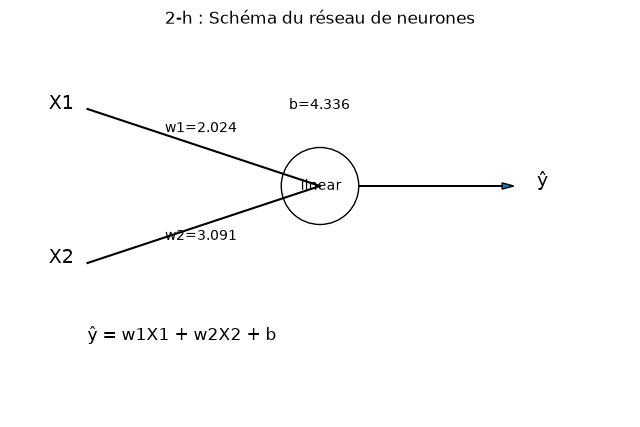

In [28]:
import matplotlib.pyplot as plt

W_nn, bias_nn = model_nn.layers[0].get_weights()

w1 = W_nn[0,0]
w2 = W_nn[1,0]
b = bias_nn[0]

plt.figure(figsize=(8,5))

# Entrées
plt.text(0.5,2,"X1",fontsize=14)
plt.text(0.5,0,"X2",fontsize=14)

# Connexions
plt.plot([1,4],[2,1],'k')
plt.plot([1,4],[0,1],'k')

plt.text(2.0,1.7,f"w1={w1:.3f}")
plt.text(2.0,0.3,f"w2={w2:.3f}")

# Neurone
circle = plt.Circle((4,1),0.5,fill=False)
plt.gca().add_patch(circle)

plt.text(3.75,0.95,"linear")

# Biais
plt.text(3.6,2.0,f"b={b:.3f}")

# Sortie
plt.arrow(4.5,1,2,0,
          head_width=0.08,
          head_length=0.15,
          length_includes_head=True)

plt.text(6.8,1,"ŷ",fontsize=14)

plt.text(1,-1,
         "ŷ = w1X1 + w2X2 + b",
         fontsize=12)

plt.title("2-h : Schéma du réseau de neurones")

plt.xlim(0,8)
plt.ylim(-2,3)

plt.axis('off')

plt.show()

### 2-i : Régularisation (Tuning)

Les techniques de régularisation deviennent importantes lorsque le modèle présente un phénomène de surapprentissage (overfitting), c'est-à-dire lorsqu'il obtient de très bonnes performances sur les données d'entraînement mais de mauvaises performances sur les données de test.

Les principales techniques de régularisation sont :

- L1 Regularization
- L2 Regularization
- Dropout
- Early Stopping

Dans ce problème de régression simple, la régularisation n'est pas indispensable car le réseau possède seulement trois paramètres (deux poids et un biais). Cependant, elle devient importante pour des réseaux plus complexes ou lorsque la quantité de données est limitée.

In [29]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

print("Poids :")
print(W_nn)

print("\nBiais :")
print(bias_nn)

Poids :
[[2.0243833]
 [3.0905945]]

Biais :
[4.3364744]


<h2>3) Prédiction en utilisant le modèle</h2>

In [30]:
yhat_nn=model_nn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


In [31]:
yhat_nn=yhat_nn.flatten()
print(yhat_nn)

[40.842815 42.980125 37.598816 27.879578 41.45492  34.484055 17.264282
 24.811039 30.51854  46.268192 17.6338   17.566349 34.656647 37.353195
 23.787804 18.76279  25.270668 53.04363  48.47983  26.18489 ]


In [32]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)

Poids : [2.0243833 3.0905945]
Biais : [4.3364744]


In [33]:
yhat_manual = (X_test @ W_nn + bias_nn).flatten()
print("Premieres predictions manuelles :", yhat_manual[:5])
print("Predictions identiques a predict :", np.allclose(yhat_nn, yhat_manual))


Premieres predictions manuelles : [40.84281495 42.98012308 37.59881367 27.87957797 41.45492282]
Predictions identiques a predict : True


<h2>4) Evaluation du modèle</h2>

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
=== TRAINING SET ===
MSE : 3.996434376794022
R² : 0.9514396202969911


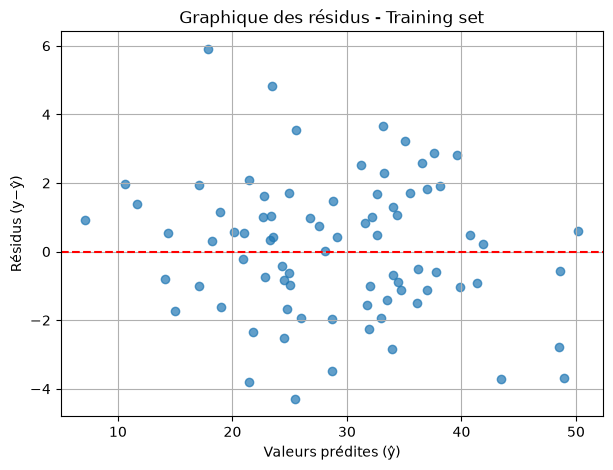

In [34]:
yhat_train = model_nn.predict(X_train).flatten()

mse_train = mean_squared_error(y_train, yhat_train)
r2_train = r2_score(y_train, yhat_train)

print("=== TRAINING SET ===")
print("MSE :", mse_train)
print("R² :", r2_train)

residus = y_train - yhat_train

plt.figure(figsize=(7,5))

plt.scatter(yhat_train, residus, alpha=0.7)

plt.axhline(0,
            color='red',
            linestyle='--')

plt.xlabel("Valeurs prédites (ŷ)")
plt.ylabel("Résidus (y−ŷ)")
plt.title("Graphique des résidus - Training set")

plt.grid(True)

plt.show()

## Interprétation

Les résidus sont globalement répartis autour de zéro.

Aucune tendance particulière n'est observée.

Le modèle semble correctement ajusté aux données d'apprentissage.

In [35]:
mse_test = mean_squared_error(y_test, yhat_nn)
r2_test = r2_score(y_test, yhat_nn)

print("=== TEST SET ===")
print("MSE :", mse_test)
print("R² :", r2_test)

=== TEST SET ===
MSE : 3.593085710516271
R² : 0.9681008238383947


<h1>From scratch</h1>


<h1 style="color: red;"> Section 3 :Régression linéaire from scratch </h1>


<h2>Modèle (version1) de régression linéaire from scratch avec utilisation des matrices</h2>


In [36]:
learning_rate = 0.001
epochs = 10000

# Initialisation des paramètres
W = np.array([[0.0], [0.0]])
b = 0.0

# Reshape y_train
y_train = y_train.reshape(-1, 1)
n = len(X_train)

# Entraînement
for epoch in range(epochs):

    y_pred = X_train @ W + b

    error = y_pred - y_train

    # Gradients
    dW = (1/n) * (X_train.T @ error)
    db = (1/n) * np.sum(error)

    # Mise à jour
    W = W - learning_rate * dW
    b = b - learning_rate * db

# Résultats
print("Paramètres ajustés:")
print(f"W = \n{W}")
print(f"b = {b:.4f}")

Paramètres ajustés:
W = 
[[2.07296569]
 [3.14674557]]
b = 3.7524


In [37]:
for epoch in range(epochs):

    y_pred = X_train @ W + b
    error = y_pred - y_train

    dW = (1/n) * (X_train.T @ error)
    db = (1/n) * np.sum(error)

    W = W - learning_rate * dW
    b = b - learning_rate * db

In [38]:
yhat_scratch = (X_test @ W + b).flatten()

print(yhat_scratch[:5])
print(yhat_nn[:5])

[40.68580278 42.80245814 37.51693657 27.90182116 41.30770125]
[40.842815 42.980125 37.598816 27.879578 41.45492 ]


In [39]:
mse_scratch = mean_squared_error(y_test, yhat_scratch)
r2_scratch = r2_score(y_test, yhat_scratch)

print("Scratch - MSE:", mse_scratch)
print("Scratch - R2 :", r2_scratch)
print("Poids appris :", W.flatten())
print("Biais appris :", b)

Scratch - MSE: 3.542222735551399
Scratch - R2 : 0.9685523819500643
Poids appris : [1.98790998 3.04711337]
Biais appris : 4.762014750338077


Le modèle implémenté sans sklearn donne des résultats proches du réseau de neurones TensorFlow. 
Les petites différences sont dues aux méthodes d'optimisation utilisées.

# Conclusion

Le réseau de neurones TensorFlow a obtenu de bonnes performances avec :

- MSE ≈ 3.59
- R² ≈ 0.968

L'implémentation manuelle par descente de gradient permet d'obtenir des résultats proches de TensorFlow.

Les écarts observés proviennent des différences d'optimisation et du nombre d'itérations utilisées.